In [1]:
from itertools import combinations, combinations_with_replacement

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from  sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

In [2]:
X = 6 * np.random.rand(200,1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200,1)

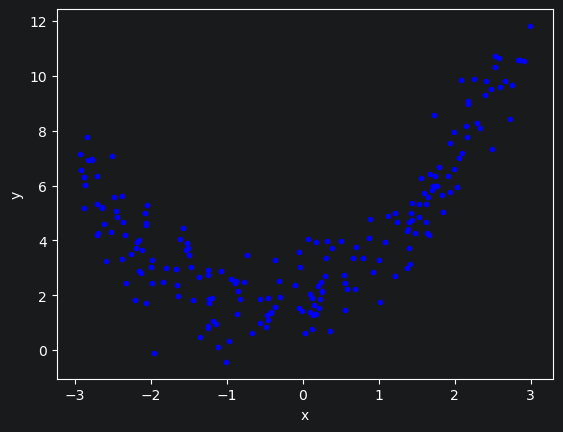

In [3]:
plt.plot(X,y,'b.')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
y_pred = lr.predict(X_test)
r2_score(y_test, y_pred)

0.22260520921466642

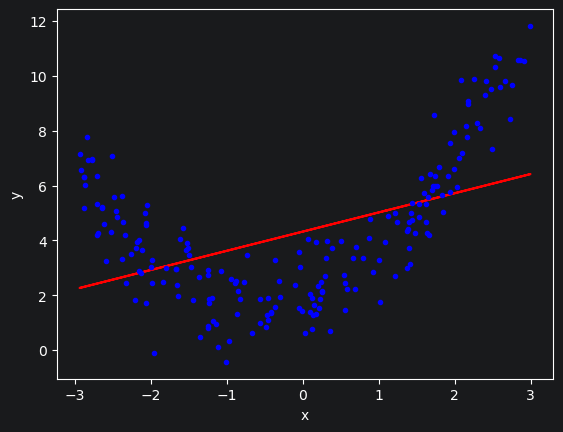

In [7]:
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X,y,'b.')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## Applying Polynomial linear Regression
### Degree 2

In [8]:
poly = PolynomialFeatures(degree = 2)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [9]:
print(X_train[0])
print(X_train_trans[0])

[1.08431081]
[1.         1.08431081 1.17572992]


Include_bias parameter
`poly = PolynomialFeatures(degree = 2, include_bias = False)`

In [10]:
lr = LinearRegression()
lr.fit(X_train_trans, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
y_pred = lr.predict(X_test_trans)
r2_score(y_test, y_pred)

0.8634347432639866

In [12]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.86694269 0.81500299]]
[1.91368988]


In [13]:
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

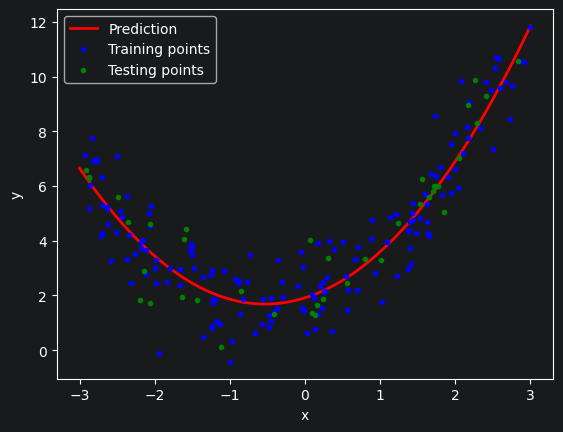

In [14]:
plt.plot(X_new,y_new,'r-', linewidth=2,label='Prediction')
plt.plot(X_train,y_train,'b.',label='Training points')
plt.plot(X_test,y_test,'g.',label='Testing points')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

## Implement `Polynomial_Regression` class from scratch

In [15]:
import numpy as np
from itertools import combinations_with_replacement

class PolynomialRegression:

    def __init__(self, degree=2):
        self.degree = degree
        self.coef_ = None   # theta

    # 🔹 Step 1: Polynomial Feature Generator
    def _poly_features(self, X):
        n_samples, n_features = X.shape

        features = [np.ones(n_samples)]  # bias column

        for d in range(1, self.degree + 1):
            for comb in combinations_with_replacement(range(n_features), d):
                feature = np.ones(n_samples)
                for i in comb:
                    feature *= X[:, i]
                features.append(feature)

        return np.column_stack(features)

    # 🔹 Step 2: Fit using Normal Equation
    def fit(self, X, y):
        X_poly = self._poly_features(X)

        # Normal equation
        self.coef_ = np.linalg.inv(X_poly.T @ X_poly) @ X_poly.T @ y

    # 🔹 Step 3: Prediction
    def predict(self, X):
        X_poly = self._poly_features(X)
        return X_poly @ self.coef_

In [16]:
# Sample data
X = np.array([[2, 3],
              [4, 5],
              [6, 7]])
y = np.array([10, 20, 30])

model = PolynomialRegression(degree=2)
model.fit(X, y)

y_pred = model.predict(X)

print("Coefficients:", model.coef_)
print("Predictions:", y_pred)

Coefficients: [-6.64748325e+14 -6.64748325e+14  6.64748325e+14 -2.96875000e+01
  1.45312500e+01  2.12500000e+01]
Predictions: [  95.5  -84.5 -216. ]
